In [5]:
#@title Import Dependencies

import typing
import numpy.typing as npt

import os
import copy

from types import MethodType
from datetime import datetime


import numpy as np
import pandas as pd

from matplotlib import pyplot as plt 
from tqdm import tqdm 
from sklearn.metrics import ConfusionMatrixDisplay
from scipy.stats import ortho_group

import torch
import torchmetrics

from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset, random_split, Subset

from torchvision.datasets import CIFAR10, CIFAR100
from torchvision import transforms
from torchvision.transforms import InterpolationMode, Resize, ToTensor
from torchvision.datasets.folder import pil_loader
from torchvision.models import resnet18

import pytorch_lightning as pl

from torchmetrics.classification import BinaryAUROC

In [13]:
DEVICE = "cpu"

In [14]:
def create_resnet18_with_num_classes(num_classes):

    model = resnet18()
    # why we use this? (See Florian?)
    model.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
    model.maxpool = nn.Identity()

    model.avgpool = nn.AvgPool2d(kernel_size=4)
    model.fc = nn.Linear(512, num_classes)
    model.num_classes = num_classes

    return model

def load_model(dataset):

    num_classes = dict(
        cifar10=10,
        cifar100=100
    )[dataset]

    teacher = create_resnet18_with_num_classes(num_classes)

    if dataset == "cifar10":
        print("Loading `cifar10` model")
        url = "https://tubcloud.tu-berlin.de/s/Ymy9WjzizxraqJy/download/resnet18-cifar10.pth"
    elif dataset == "cifar100":
        print("Loading `cifar100` model")
        url = "https://tubcloud.tu-berlin.de/s/xZ29d76Sz29M9Qa/download/resnet18-cifar100.pth"

    teacher.load_state_dict(torch.hub.load_state_dict_from_url(url))
    teacher = teacher.eval()

    return teacher.to(DEVICE)

In [15]:
CIFAR10_NORM = [[0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010]]

TRANSFORM_NORM = transforms.Normalize(*CIFAR10_NORM)

In [21]:

@torch.no_grad()
def compute_auroc(model, dl, selected_classes):

    class1, class2 = selected_classes

    metric = BinaryAUROC()
    for x, y in dl:
        logits = model(x.to(DEVICE)).detach().cpu()

        logodd = logits[:, class1] - logits[:, class2]

        assert np.logical_or(y == class1, y == class2).all()

        ybin = np.where(y == class1, 0, 1)
        metric.update(logodd, torch.from_numpy(ybin))

    auroc = float(metric.compute())
    auroc = np.max([auroc, 1-auroc])

    return auroc

In [17]:
def construct_dataset(
    basedataset, 
    selected_classes, 
    batch_size=128,
    num_workers=2, 
):

    assert len(selected_classes) == 2



    assert basedataset in ["cifar10", "cifar100"]
        
    if basedataset == "cifar10":
        num_classes = 10
        ds_class = CIFAR10
    else:
        num_classes = 100
        ds_class = CIFAR100


    tf = transforms.Compose([transforms.ToTensor(), TRANSFORM_NORM])

    full_train_ds = ds_class(root="./datasets", train=True, transform=tf,  download=True)
    full_val_ds = ds_class(root="./datasets", train=False, transform=tf,  download=True)


    train_subset = Subset(
        full_train_ds,
        np.argwhere(np.isin(full_train_ds.targets, selected_classes)).reshape(-1).tolist()
    )

    val_subset = Subset(
        full_val_ds,
        np.argwhere(np.isin(full_val_ds.targets, selected_classes)).reshape(-1).tolist()
    )

    train_loader = DataLoader(train_subset,  num_workers=num_workers, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_subset,  num_workers=num_workers, batch_size=batch_size, )


    return  train_loader, val_loader

In [18]:
_, val_loader = construct_dataset("cifar100", [35, 98])

Files already downloaded and verified
Files already downloaded and verified


In [19]:
model = load_model("cifar100")

Loading `cifar100` model


In [22]:
compute_auroc(model, val_loader, [35, 98])

0.7932000160217285

In [31]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [44]:
model = load_model("cifar100")

# model.layer3[1].relu = nn.Identity()
# model.layer1[1].relu = nn.ReLU(inplace=True)

selected_classes = [20, 98]
compute_auroc(
    model,
#     val_loader,
    construct_dataset("cifar100", selected_classes)[1],
    selected_classes
)

Loading `cifar100` model
Files already downloaded and verified
Files already downloaded and verified


0.9997000003058929

In [55]:
weight = model.fc.weight.detach()

In [56]:
weight = F.normalize(weight, dim=1).detach()

In [80]:
cossim = weight @ weight.T
cossim = cossim.numpy()

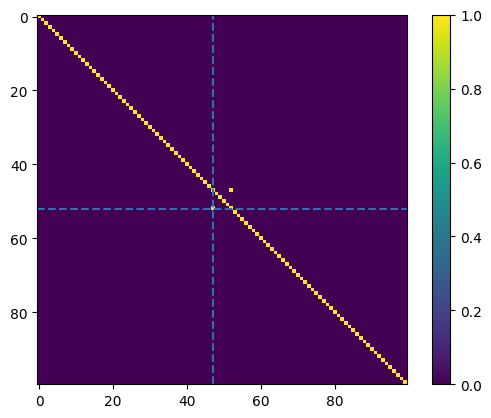

In [87]:
plt.imshow(
    cossim >= np.max(cossim - np.eye(100)),
)
plt.colorbar()
plt.axvline(47, ls="--")
plt.axhline(52, ls="--")